In [1]:
# Import necessary libraries for image processing and machine learning

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

C:\Users\Tanishka kulkarni\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# Define dataset path
dataset_path = "Dataset"

In [3]:
# Load images and convert them into numerical features

data = []
labels = []

for label in range(10):
    
    folder = os.path.join(dataset_path, str(label))
    
    for img_name in os.listdir(folder):
        
        img_path = os.path.join(folder, img_name)
        
        try:
            image = cv2.imread(img_path)
            image = cv2.resize(image, (64,64))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            
            data.append(image.flatten())
            labels.append(label)
        
        except:
            continue

X = np.array(data)
y = np.array(labels)

print("Total images loaded:", len(X))
print("Feature shape:", X.shape)

Total images loaded: 2062
Feature shape: (2062, 4096)


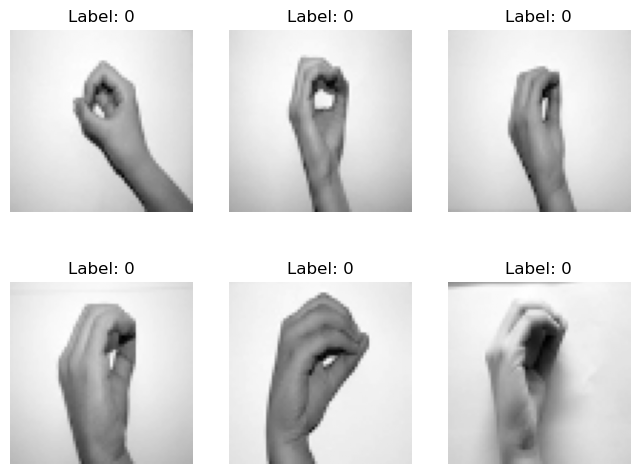

In [4]:
# Display some sample gesture images

plt.figure(figsize=(8,6))

for i in range(6):
    
    plt.subplot(2,3,i+1)
    plt.imshow(X[i].reshape(64,64), cmap="gray")
    plt.title("Label: " + str(y[i]))
    plt.axis("off")

plt.show()

In [5]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1649
Testing samples: 413


In [6]:
# Train SVM classifier

model = SVC(kernel='rbf')

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [7]:
# Predict gestures for test data

y_pred = model.predict(X_test)

In [8]:
# Evaluate model accuracy

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8087167070217918

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        40
           1       0.87      0.94      0.90        48
           2       0.84      0.74      0.79        50
           3       0.93      0.74      0.83        35
           4       0.53      0.78      0.63        32
           5       0.85      0.92      0.89        38
           6       0.85      0.68      0.76        41
           7       0.64      0.74      0.68        38
           8       0.87      0.73      0.80        45
           9       0.87      0.87      0.87        46

    accuracy                           0.81       413
   macro avg       0.82      0.81      0.81       413
weighted avg       0.82      0.81      0.81       413



In [9]:
# Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[37  0  0  0  2  0  1  0  0  0]
 [ 0 45  0  1  1  0  0  1  0  0]
 [ 1  3 37  1  0  0  1  7  0  0]
 [ 1  0  2 26  2  2  0  0  1  1]
 [ 1  0  0  0 25  1  3  2  0  0]
 [ 0  0  0  0  1 35  0  0  0  2]
 [ 0  0  0  0  8  0 28  3  2  0]
 [ 0  1  3  0  4  0  0 28  2  0]
 [ 0  2  1  0  2  1  0  3 33  3]
 [ 0  1  1  0  2  2  0  0  0 40]]


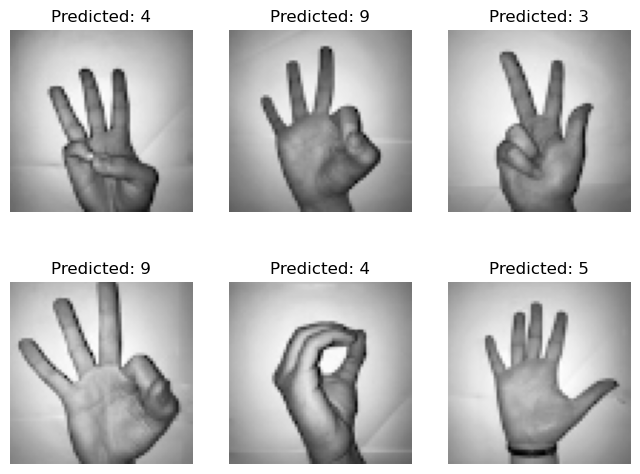

In [10]:
# Show predictions for test images

plt.figure(figsize=(8,6))

for i in range(6):
    
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i].reshape(64,64), cmap="gray")
    plt.title("Predicted: " + str(y_pred[i]))
    plt.axis("off")

plt.show()